# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 6. Поиск эволюционирующих шаблонов с помощью матричного профиля ряда.**

## **Часть 1.** Поиск цепочек временного ряда.

Импорт библиотек и модулей

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stumpy
from sklearn.metrics import mean_squared_error

В первом задании вам предстоит выполнить поиск эволюционирующих шаблонов временного ряда. Выполните считывание набора данных [Rotation Matrix](datasets/Rotation%20Matrix.txt), найдите в нем самую длинную цепочку и выведите индексы начала звеньев этой цепочки.

In [3]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


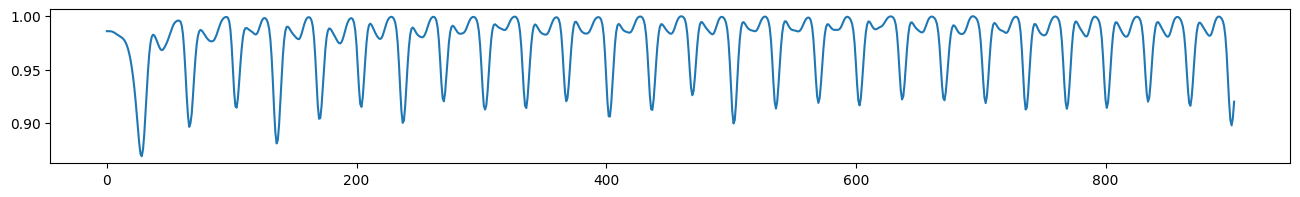

In [4]:
fig, ax = plt.subplots(figsize=(16, 2))
ts_url = '/gdrive/My Drive/Colab Notebooks/АиПВРМИИ/06/Rotation Matrix.txt' # для colab
ts = np.loadtxt(ts_url)
ax.plot(ts)

In [5]:
# Установка длины подпоследовательности (окна)
m = 50

# Вычисление матричного профиля
# Функция stump возвращает матричный профиль, индексы, а также левые и правые индексы
mp = stumpy.stump(ts, m)

# mp[:, 2] содержит левые индексы (mp.left_I_), а mp[:, 3] - правые (mp.right_I_)
# Эти индексы необходимы для поиска цепочек
all_chains, longest_chain = stumpy.allc(mp[:, 2], mp[:, 3])

print(f"Индексы начала звеньев самой длинной цепочки:")
print(longest_chain)

Индексы начала звеньев самой длинной цепочки:
[ 16  55 124 490 524 591]


❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Алгоритм обнаружил в данных повторяющиеся шаблоны, которые похожи друг на друга, но при этом постепенно изменяются или "дрейфуют" во времени.

Из всех возможных эволюционирующих шаблонов в данных, найденная цепочка является самой длинной, то есть состоит из наибольшего числа последовательных звеньев (в данном случае, 6 звеньев).

Каждое число в массиве — это начальная точка (индекс) во временном ряде, с которой начинается очередное звено этой цепочки.

Звенья появляются не через равные промежутки времени. Это говорит о том, что эволюционирующий процесс, который представляет эта цепочка, происходит с разной периодичностью.

## **Часть 2. Визуализация цепочек**

Выполните визуализацию найденных в прошлом задании цепочек: постройте график временного ряда, на котором выделены звенья цепочек. Также постройте график, на котором изображены только сами звенья.

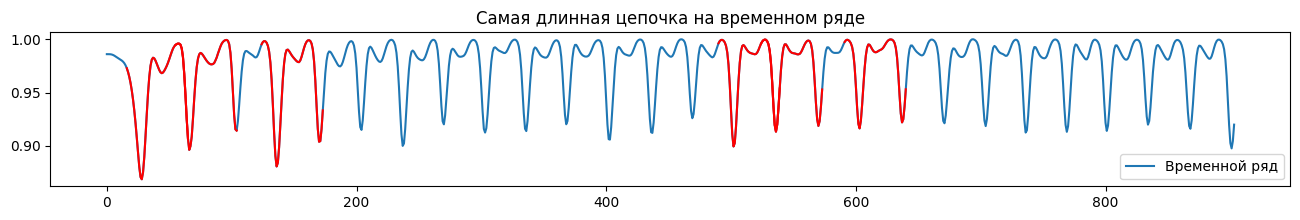

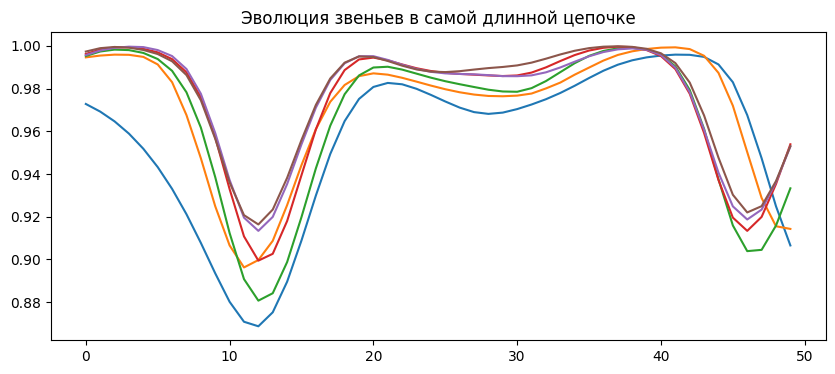

In [6]:
# Построение графика временного ряда с выделенными звеньями
fig, ax = plt.subplots(figsize=(16, 2))
ax.plot(ts, label='Временной ряд')

# Выделение каждого звена цепочки на графике
for i in longest_chain:
    ax.plot(range(i, i + m), ts[i:i + m], c='red')
ax.legend()
plt.title('Самая длинная цепочка на временном ряде')
plt.show()

# Построение графика только звеньев цепочки
fig, ax = plt.subplots(figsize=(10, 4))
for i in longest_chain:
    ax.plot(ts[i:i + m])
plt.title('Эволюция звеньев в самой длинной цепочке')
plt.show()

❓ Проанализируйте и изложите содержательный смысл полученных результатов.

График "Самая длинная цепочка на временном ряде" наглядно подтверждает, что найденные алгоритмом звенья действительно соответствуют похожим по форме участкам временного ряда.

График "Эволюция звеньев в самой длинной цепочке" показывает, что все звенья очень похожи по своей основной форме (поэтому они и были объединены в одну цепочку), но при этом не являются точными копиями друг друга.

Можно заметить, что от одного звена к другому происходят постепенные, направленные изменения. Например, глубина "провала" у разных звеньев немного отличается, а пики могут быть смещены или иметь разную высоту.

## **Часть 3.** Предсказывание значений ряда на основе цепочек.

Предскажите значения последнего звена цепочки, вычислив разность между двумя предыдущими звеньями цепочки. Сравните полученное предсказание с истинным значением.

Индекс предыдущего звена: 524
Индекс последнего звена: 591
Индекс фактического следующего звена: 625

Среднеквадратичная ошибка (MSE): 0.0001


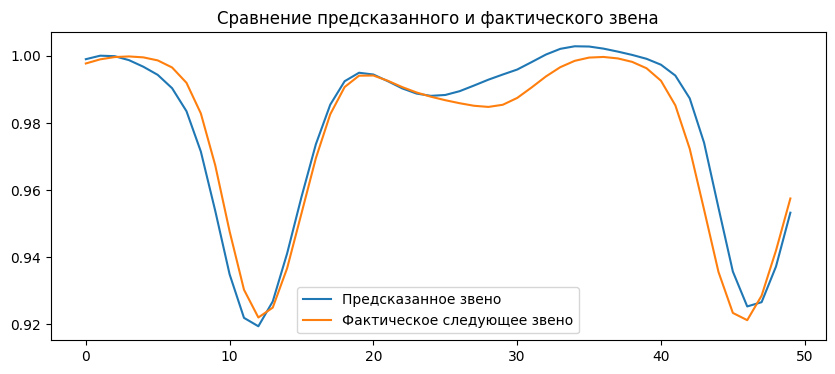

In [9]:
# Получение двух последних звеньев из найденной цепочки
chain_len = len(longest_chain)
if chain_len >= 2:
    prev_link_idx = longest_chain[-2]
    last_link_idx = longest_chain[-1]

    prev_link = ts[prev_link_idx : prev_link_idx + m]
    last_link = ts[last_link_idx : last_link_idx + m]

    # Вычисление разности (эволюции) между звеньями
    diff = last_link - prev_link

    # Предсказание следующего звена
    predicted_link = last_link + diff

    # Поиск фактического следующего звена, если оно существует
    # Для этого найдем ближайшего правого соседа последнего звена
    actual_next_idx = int(mp[last_link_idx, 3]) # Используем правый индекс из mp

    print(f"Индекс предыдущего звена: {prev_link_idx}")
    print(f"Индекс последнего звена: {last_link_idx}")
    print(f"Индекс фактического следующего звена: {actual_next_idx}")

    # Визуализация и сравнение
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(predicted_link, label='Предсказанное звено')

    # Проверка, что следующее звено существует
    if actual_next_idx != -1 and (actual_next_idx + m) <= len(ts):
        actual_next_link = ts[actual_next_idx : actual_next_idx + m]
        ax.plot(actual_next_link, label='Фактическое следующее звено')

        # Расчет ошибки
        mse = mean_squared_error(actual_next_link, predicted_link)
        print(f"\nСреднеквадратичная ошибка (MSE): {mse:.4f}")

    else:
        print("\nФактическое следующее звено не найдено в данных.")

    ax.legend()
    plt.title('Сравнение предсказанного и фактического звена')
    plt.show()

else:
    print("Цепочка слишком коротка для предсказания (требуется минимум 2 звена).")

❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Синяя линия - это форма подпоследовательности, которую мы спрогнозировали. Прогноз был получен путем вычисления "разницы" между двумя последними известными звеньями и прибавления этой разницы к последнему звену.

Визуальный анализ показывает, что обе линии практически совпадают. Они имеют одинаковую общую форму, глубину и расположение ключевых точек (минимумов и максимумов)

MSE измеряет среднее квадратов отклонений между предсказанными и фактическими значениями. Значение 0.0001 является чрезвычайно низким, что количественно подтверждает то, что мы видим на графике — предсказание очень близко к реальности.